In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"truptighate","key":"c8d1e7ee111130a9a1d7ee22b85d80ef"}'}

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c ieee-fraud-detection

100% 118M/118M [00:00<00:00, 168MB/s]



In [ ]:
!unzip ieee-fraud-detection.zip

Archive:  ieee-fraud-detection.zip
  inflating: sample_submission.csv   
  inflating: test_identity.csv       
  inflating: test_transaction.csv    
  inflating: train_identity.csv      
  inflating: train_transaction.csv   


In [ ]:
import pandas as pd

df = pd.read_csv('train_transaction.csv', nrows=100000)
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0,97439
1,2561


In [ ]:
df['isFraud'].value_counts(normalize=True)

,proportion
isFraud,
0,0.97439
1,0.02561


In [ ]:
df[['TransactionAmt']].describe()

,TransactionAmt
count,100000.000000
mean,130.743351
std,206.024684
min,0.292000
25%,45.000000
50%,75.000000
75%,135.950000
max,4829.950000


In [ ]:
df.groupby('isFraud')['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,97439.0,130.664052,206.483276,1.000,45.0,75.000,134.95,4829.95
1,2561.0,133.760444,187.758261,0.292,40.0,78.788,150.00,3081.97


In [ ]:
df[['TransactionDT']].describe()

,TransactionDT
count,1.000000e+05
mean,1.135124e+06
std,5.733484e+05
min,8.640000e+04
25%,6.537488e+05
50%,1.189342e+06
75%,1.643471e+06
max,2.006364e+06


In [ ]:
df['hour'] = (df['TransactionDT'] // 3600) % 24
df[['hour']].head()

,hour
0,0
1,0
2,0
3,0
4,0


In [ ]:
df.groupby('hour')['isFraud'].mean()

,isFraud
hour,
0,0.024349
1,0.026320
2,0.021420
3,0.029234
4,0.037344
5,0.046097
6,0.045576
7,0.032457
8,0.052764


<Axes: xlabel='hour'>

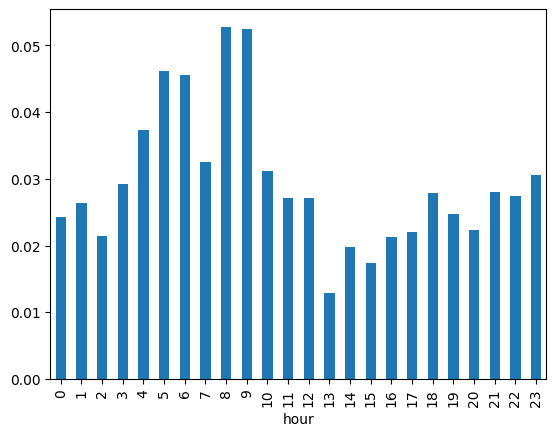

In [ ]:
df.groupby('hour')['isFraud'].mean().plot(kind='bar')

In [ ]:
df.groupby('hour')['TransactionAmt'].mean()

,TransactionAmt
hour,
0,122.747452
1,113.949421
2,113.751942
3,102.976298
4,101.330952
5,92.705878
6,105.774989
7,115.985930
8,128.151462


In [ ]:
df.groupby('hour').agg({
    'isFraud': 'mean',
    'TransactionAmt': 'mean'
})

,isFraud,TransactionAmt
hour,,
0,0.024349,122.747452
1,0.026320,113.949421
2,0.021420,113.751942
3,0.029234,102.976298
4,0.037344,101.330952
5,0.046097,92.705878
6,0.045576,105.774989
7,0.032457,115.985930
8,0.052764,128.151462


Fraud is more dependent on time behavior than transaction amount.
Certain time windows show disproportionately higher fraud even with lower transaction values.

In [ ]:
df['amt_bucket'] = pd.qcut(df['TransactionAmt'], 4)

df.groupby('amt_bucket')['isFraud'].mean()

/tmp/ipykernel_39103/1023116557.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('amt_bucket')['isFraud'].mean()


,isFraud
amt_bucket,
"(0.291, 45.0]",0.028416
"(45.0, 75.0]",0.020136
"(75.0, 135.95]",0.022126
"(135.95, 4829.95]",0.031779


Fraud is not linearly increasing with amount.
Both very small and very large transactions carry higher risk.

In [ ]:
df.groupby(['hour', 'amt_bucket'])['isFraud'].mean().unstack()

/tmp/ipykernel_39103/4225987131.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['hour', 'amt_bucket'])['isFraud'].mean().unstack()


amt_bucket,"(0.291, 45.0]","(45.0, 75.0]","(75.0, 135.95]","(135.95, 4829.95]"
hour,,,,
0,0.028603,0.010785,0.022727,0.036177
1,0.016139,0.024375,0.019772,0.049546
2,0.016499,0.016345,0.021834,0.034415
3,0.024523,0.021739,0.037457,0.037975
4,0.042627,0.040097,0.022059,0.044146
5,0.027375,0.075786,0.028640,0.054878
6,0.059701,0.037415,0.027344,0.055556
7,0.033520,0.028736,0.047297,0.020548
8,0.027523,0.043011,0.057692,0.086957


Fraud risk is contextual, not isolated.
It depends on combination of time + transaction amount, not either alone.

Transactions with high amount during peak fraud hours (8–9) show significantly elevated fraud probability.

In [ ]:
df['high_risk'] = ((df['hour'].isin([8,9])) & (df['TransactionAmt'] > 135.95)).astype(int)

df.groupby('high_risk')['isFraud'].mean()

,isFraud
high_risk,
0,0.025425
1,0.129944


Combining simple rules (time + amount) dramatically improves fraud detection power.



In [ ]:
df['high_risk'].value_counts(normalize=True)

,proportion
high_risk,
0,0.99823
1,0.00177


In [ ]:
df['medium_risk'] = ((df['hour'].isin([5,6,8,9])) & (df['TransactionAmt'] > 75)).astype(int)

df.groupby('medium_risk')['isFraud'].mean()

,isFraud
medium_risk,
0,0.025218
1,0.049413


When you relax conditions, coverage increases but precision drops

In [ ]:
df['medium_risk'].value_counts(normalize=True)

,proportion
medium_risk,
0,0.98381
1,0.01619


A combination of strict and relaxed rules can balance fraud detection between precision and coverage.

In [ ]:
df['risk_score'] = df['high_risk']*2 + df['medium_risk']
df.groupby('risk_score')['isFraud'].mean()

,isFraud
risk_score,
0,0.025218
1,0.039528
3,0.129944


As risk score increases, fraud probability increases sharply.

In [ ]:
df['risk_score'].value_counts(normalize=True)

,proportion
risk_score,
0,0.98381
1,0.01442
3,0.00177


A tiny fraction of transactions carries disproportionately high fraud risk.

<Axes: xlabel='risk_score'>

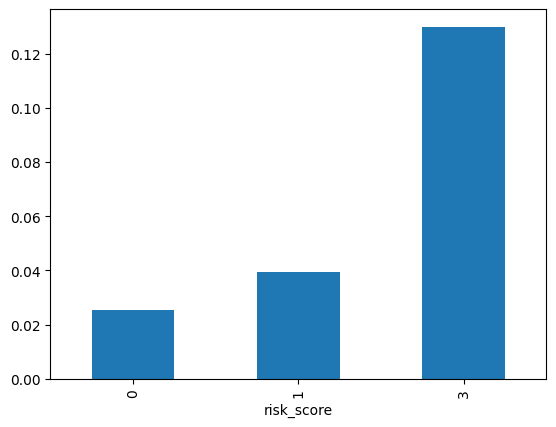

In [ ]:
df.groupby('risk_score')['isFraud'].mean().plot(kind='bar')

In [ ]:
df[['TransactionAmt','hour','risk_score','isFraud']].head(20)

,TransactionAmt,hour,risk_score,isFraud
0,68.500,0,0,0
1,29.000,0,0,0
2,59.000,0,0,0
3,50.000,0,0,0
4,50.000,0,0,0
5,49.000,0,0,0
6,159.000,0,0,0
7,422.500,0,0,0
8,15.000,0,0,0
9,117.000,0,0,0


In [ ]:
df.sample(20)[['TransactionAmt','hour','risk_score','isFraud']]

,TransactionAmt,hour,risk_score,isFraud
51296,280.00,22,0,0
94367,50.00,15,0,0
26054,47.95,18,0,0
18152,95.00,16,0,0
88591,75.00,15,0,0
35548,30.00,0,0,0
3463,50.00,19,0,0
74641,39.00,23,0,0
40882,200.00,16,0,0
33795,60.00,18,0,1


In [ ]:
df[df['risk_score'] > 0][['TransactionAmt','hour','risk_score','isFraud']].sample(20)

,TransactionAmt,hour,risk_score,isFraud
916,325.000,6,1,0
87497,250.000,6,1,0
52803,275.990,8,3,0
17319,85.000,8,1,0
99973,100.000,5,1,0
32585,176.999,6,1,0
40058,2680.990,9,3,1
81765,100.000,5,1,0
1090,625.000,8,3,0
13178,210.950,8,3,0


I observed that fraud is not driven by transaction amount alone. By combining temporal patterns with transaction value, we created a rule-based scoring system where high-risk conditions showed ~5x higher fraud probability.

In [45]:
df.sample(5000).to_csv('sample_data.csv', index=False)